In [1]:
import os
import torch

# Check GPU
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

# Set up data folder
os.makedirs('data', exist_ok=True)

True
Tesla T4


In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

batch_size    = 32
block_size    = 256
max_iters     = 5000
eval_interval = 500
learning_rate = 3e-4
device        = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters    = 200
n_embd        = 384
n_head        = 6
n_layer       = 6
dropout       = 0.2

print(f"Using device: {device}")

#Loading
with open('/kaggle/input/datasets/akshatakhouri/math-txt/math.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Dataset size: {len(text):,} characters")

#Tokens
chars      = sorted(list(set(text)))
vocab_size = len(chars)
stoi       = {ch: i for i, ch in enumerate(chars)}
itos       = {i: ch for i, ch in enumerate(chars)}
encode     = lambda s: [stoi[c] for c in s]
decode     = lambda l: ''.join([itos[i] for i in l])

print(f"Vocab size: {vocab_size}")

#Data split
data       = torch.tensor(encode(text), dtype=torch.long)
n          = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]

#Data loading
def get_batch(split):
    d  = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x  = torch.stack([d[i:i+block_size] for i in ix])
    y  = torch.stack([d[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

#Loss calculations
@torch.no_grad()
def estimate_loss(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y         = get_batch(split)
            logits, loss = model(X, Y)
            losses[k]    = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

#Model
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key     = nn.Linear(n_embd, head_size, bias=False)
        self.query   = nn.Linear(n_embd, head_size, bias=False)
        self.value   = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.attention_weights = None 

    def forward(self, x):
        B, T, C = x.shape
        k   = self.key(x)
        q   = self.query(x)
        wei = q @ k.transpose(-2, -1) * k.shape[-1]**-0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        self.attention_weights = wei
        wei = self.dropout(wei)
        v   = self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads   = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj    = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa   = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1  = nn.LayerNorm(n_embd)
        self.ln2  = nn.LayerNorm(n_embd)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table    = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks  = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f    = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T     = idx.shape
        tok_emb  = self.token_embedding_table(idx)
        pos_emb  = self.position_embedding_table(torch.arange(T, device=device))
        x        = tok_emb + pos_emb
        x        = self.blocks(x)
        x        = self.ln_f(x)
        logits   = self.lm_head(x)
        loss     = None
        if targets is not None:
            B, T, C = logits.shape
            logits  = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss    = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond     = idx[:, -block_size:]
            logits, loss = self(idx_cond)
            logits       = logits[:, -1, :]
            probs        = F.softmax(logits, dim=-1)
            idx_next     = torch.multinomial(probs, num_samples=1)
            idx          = torch.cat((idx, idx_next), dim=1)
        return idx

# Training 
torch.manual_seed(42)
model     = GPTLanguageModel()
m         = model.to(device)
print(f"Parameters: {sum(p.numel() for p in m.parameters())/1e6:.2f}M")

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss(model)
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
    xb, yb       = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

#Save the model
torch.save(model.state_dict(), '/kaggle/working/math_gpt.pt')


#Sample text
context   = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = decode(m.generate(context, max_new_tokens=500)[0].tolist())
print("Sample")
print(generated)


Using device: cuda
Dataset size: 6,757,945 characters
Vocab size: 98
Parameters: 10.81M
step 0: train loss 4.6105, val loss 4.5982
step 500: train loss 1.6001, val loss 1.5786
step 1000: train loss 1.1711, val loss 1.1449
step 1500: train loss 1.0246, val loss 0.9895
step 2000: train loss 0.9418, val loss 0.9180
step 2500: train loss 0.8939, val loss 0.8715
step 3000: train loss 0.8478, val loss 0.8376
step 3500: train loss 0.8187, val loss 0.8259
step 4000: train loss 0.7937, val loss 0.7989
step 4500: train loss 0.7773, val loss 0.7821
step 4999: train loss 0.7591, val loss 0.7645
Model saved!

--- Generated sample ---
	$(9,9)$ is slome intersect able, so each other twith two different points.  What possible sum that Melance to there worry of $99^2$ are discalars, or $13^2=17$, if the form
\[9(99 \alpha) = 129 = 13^2.\] Expanding exansidew $128^2 - 19^2$ by the equation, we having the two equations, we find that found the hother equation numbers $0<1$ and $0<98^2$ are guent $99 - 97 

In [1]:

model.eval()

#Samples
sample_texts = [
    "Problem: Find $x^2 + y^2$ if $x + y = 5$",
    "Solution: We use the identity $(x+y)^2 = x^2 + 2xy + y^2$",
    "Problem: What is the remainder when $2^{100}$ is divided by $7$?",
]

# Visualize
sample = torch.tensor(encode(sample_texts[0])).unsqueeze(0).to(device)
with torch.no_grad():
    model(sample)

# Labeling
char_labels = [c for c in sample_texts[0]]

fig, axes = plt.subplots(6, 6, figsize=(24, 24))
fig.suptitle(f'All 36 Attention Heads\nInput: "{sample_texts[0]}"', fontsize=14)

for layer in range(6):
    for head in range(6):
        ax = axes[layer][head]
        wei = model.blocks[layer].sa.heads[head].attention_weights
        wei = wei.detach().cpu()
        ax.imshow(wei[0], cmap='hot', interpolation='nearest')
        ax.set_title(f'L{layer}H{head}', fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('/kaggle/working/all_heads.png', dpi=150, bbox_inches='tight')
plt.show()



#Full head view
def visualize_head(layer_num, head_num, text):
    """Visualize 1 attention head"""
    tokens = torch.tensor(encode(text)).unsqueeze(0).to(device)
    with torch.no_grad():
        model(tokens)

    wei = model.blocks[layer_num].sa.heads[head_num].attention_weights
    wei = wei.detach().cpu()[0]

    chars = list(text)
    seq_len = len(chars)

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.imshow(wei[:seq_len, :seq_len], cmap='hot', interpolation='nearest')
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(chars, fontsize=6, rotation=90)
    ax.set_yticklabels(chars, fontsize=6)
    ax.set_xlabel('attending TO (keys)')
    ax.set_ylabel('attending FROM (queries)')
    ax.set_title(f'Layer {layer_num}, Head {head_num}\nInput: "{text}"')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/L{layer_num}_H{head_num}.png', dpi=150, bbox_inches='tight')
    plt.show()

#Specific heads
visualize_head(0, 0, sample_texts[0])
visualize_head(0, 1, sample_texts[0])
visualize_head(5, 0, sample_texts[0])
visualize_head(5, 5, sample_texts[0])


# One head with different inputs
def compare_head_across_inputs(layer_num, head_num, texts):
    fig, axes = plt.subplots(1, len(texts), figsize=(8 * len(texts), 8))
    if len(texts) == 1:
        axes = [axes]

    for i, text in enumerate(texts):
        tokens = torch.tensor(encode(text)).unsqueeze(0).to(device)
        with torch.no_grad():
            model(tokens)

        wei = model.blocks[layer_num].sa.heads[head_num].attention_weights
        wei = wei.detach().cpu()[0]

        chars = list(text)
        seq_len = len(chars)

        axes[i].imshow(wei[:seq_len, :seq_len], cmap='hot', interpolation='nearest')
        axes[i].set_xticks(range(seq_len))
        axes[i].set_yticks(range(seq_len))
        axes[i].set_xticklabels(chars, fontsize=5, rotation=90)
        axes[i].set_yticklabels(chars, fontsize=5)
        axes[i].set_title(f'Input {i+1}', fontsize=10)

    fig.suptitle(f'Layer {layer_num}, Head {head_num} — across {len(texts)} inputs', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/compare_L{layer_num}_H{head_num}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Compare head 0,0 across all sample texts
compare_head_across_inputs(0, 0, sample_texts)
compare_head_across_inputs(5, 0, sample_texts)


#Finding heads
print("Head Scores:\n")
print("Higher score\n")
print("Lower score\n")

tokens = torch.tensor(encode(sample_texts[0])).unsqueeze(0).to(device)
with torch.no_grad():
    model(tokens)

head_scores = []
for layer in range(6):
    for head in range(6):
        wei = model.blocks[layer].sa.heads[head].attention_weights
        wei = wei.detach().cpu()[0]
        # Measure concentration: max attention value averaged across positions
        concentration = wei.max(dim=-1).values.mean().item()
        head_scores.append((layer, head, concentration))
        print(f"Layer {layer} Head {head}: concentration = {concentration:.4f}")

# Sort by concentration — most specialized heads first
head_scores.sort(key=lambda x: x[2], reverse=True)
print("5 most special heads")
for layer, head, score in head_scores[:5]:
    print(f"Layer {layer} Head {head}: {score:.4f}")

print("5 least special heads")
for layer, head, score in head_scores[-5:]:
    print(f"Layer {layer} Head {head}: {score:.4f}")

NameError: name 'model' is not defined

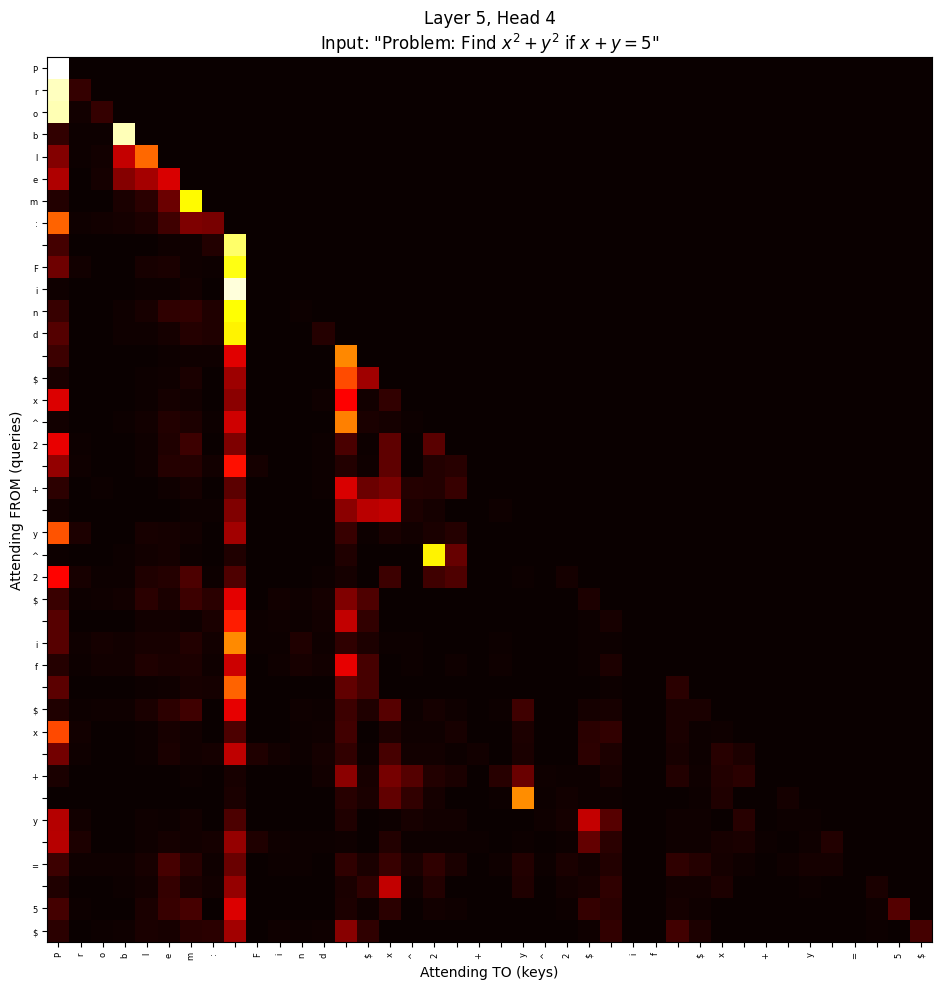

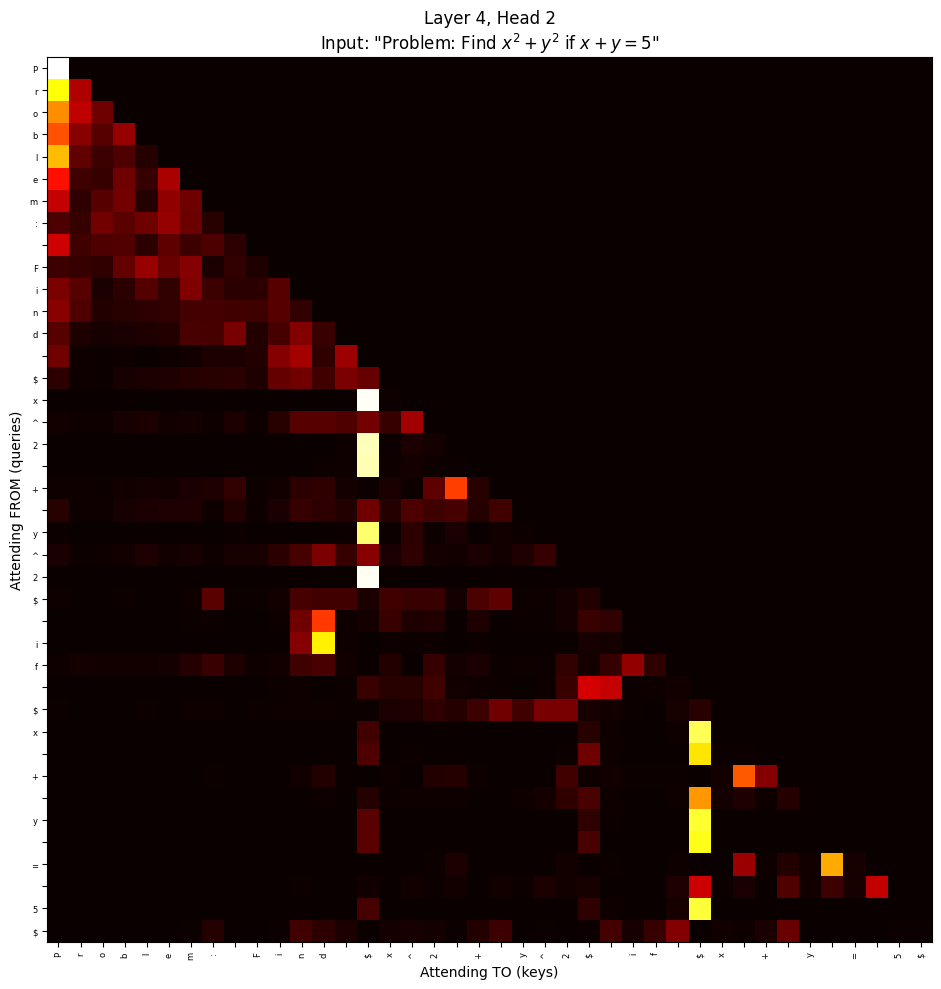

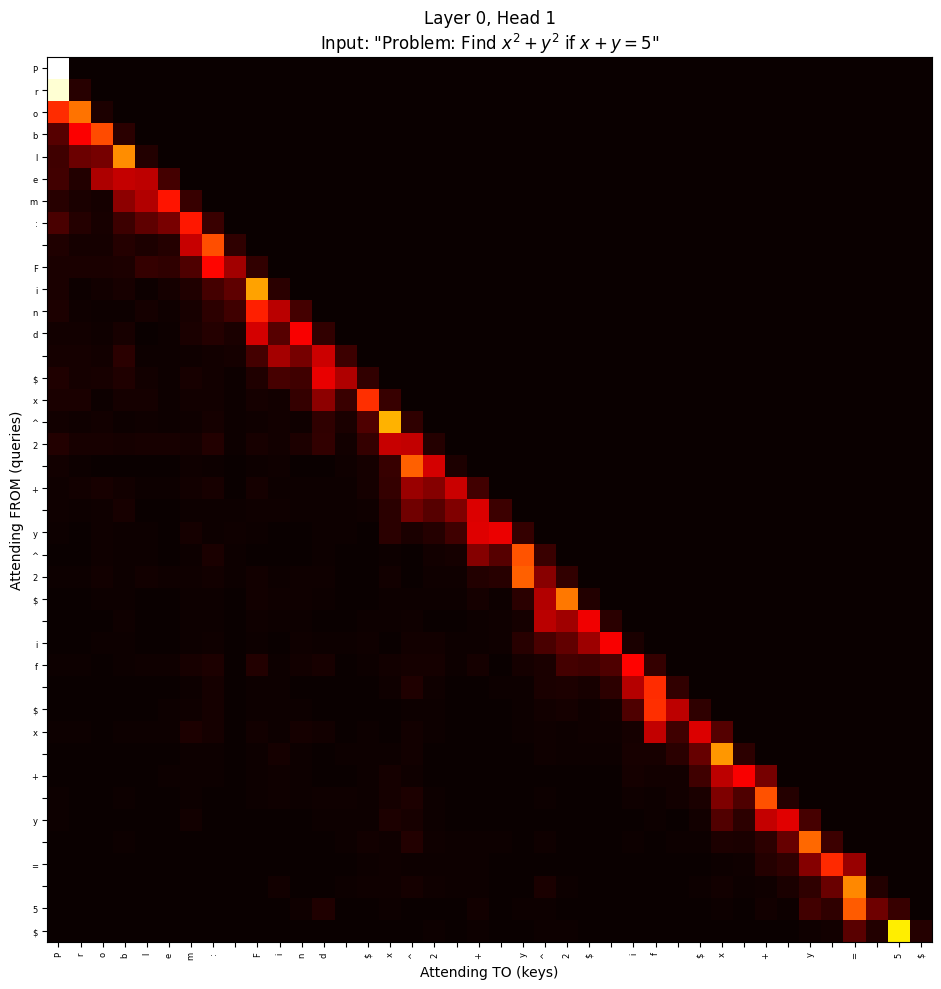

In [4]:
visualize_head(5, 4, sample_texts[0])
visualize_head(4, 2, sample_texts[0])
visualize_head(0, 1, sample_texts[0])